Trực quan hóa tất cả kết quả mô hình sau khi thực hiện quá trình hyperparameter tuning dựa trên bộ tham số cho ra r2_score trung bình cao nhất.

# 1. Import thư viện cần thiết

In [8]:
import sys
import os

# Thêm thư mục gốc của project vào sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root added: {project_root}")

Project root added: /Users/khangbinhdl/HK V/Python cho KHDL/Cuối kì


In [9]:
import json
from src.visualization.model_plots import ModelVisualizer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from src.models.io import ModelIO
from src.data.io import DataIO

# Thiết lập style
sns.set_theme(style="whitegrid")

# 2. Vẽ so sánh hiệu suất các mô hình

✓ Loaded 5 model results
✓ Best model: XGBoost


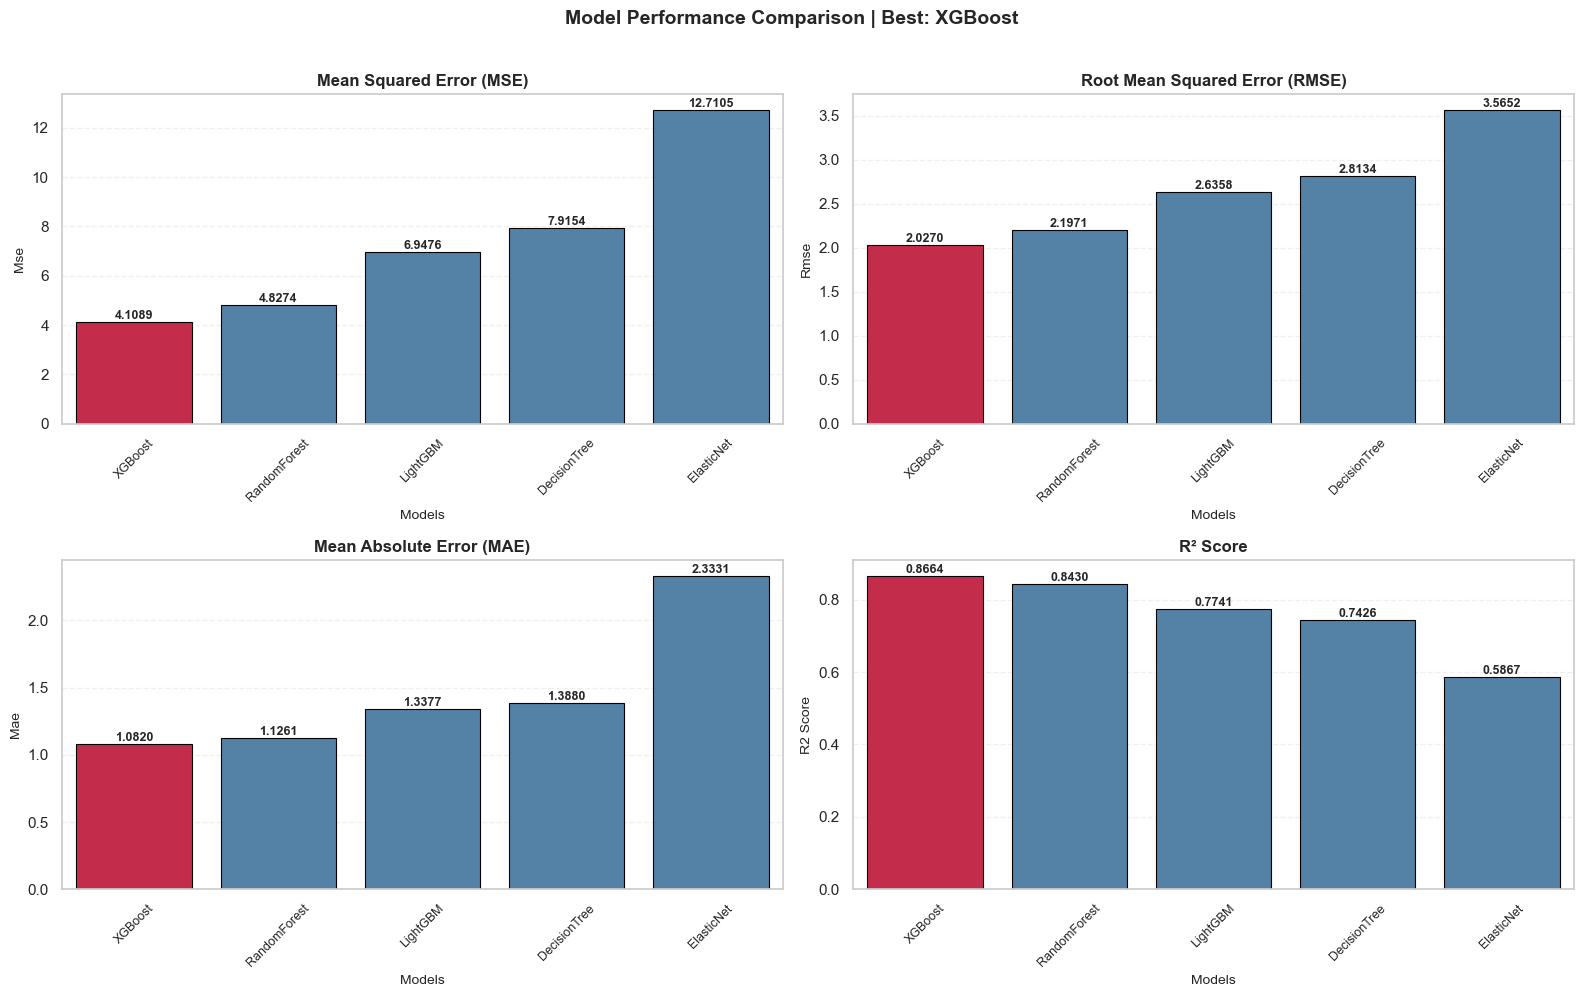

In [10]:
# Load evaluation results
results_path = os.path.join(project_root, 'outputs', 'results', 'evaluation_results.json')
with open(results_path, 'r') as f:
    results_list = json.load(f)

# Tạo evaluation_results dict với format phù hợp cho ModelVisualizer
evaluation_results = {
    'results': results_list,
    'best_model_name': min(results_list, key=lambda x: x['mse'])['model_name']
}

print(f"✓ Loaded {len(results_list)} model results")
print(f"✓ Best model: {evaluation_results['best_model_name']}")

# Vẽ so sánh tất cả models
visualizer = ModelVisualizer(evaluation_results)
output_path = os.path.join(project_root, 'outputs', 'plots', 'model_comparison_all.png')
visualizer.plot_model_comparison(save_path=None)

# 3. Vẽ biểu đồ quan trọng của các đặc trưng

In [11]:
models_dir = os.path.join(project_root, 'outputs', 'models')
model_files = [
    'ElasticNet.joblib',
    'DecisionTree.joblib',
    'RandomForest.joblib',
    'XGBoost.joblib',
    'LightGBM.joblib',
]

models = {}
for model_file in model_files:
    model_path = os.path.join(models_dir, model_file)
    model_name = model_file.replace('.joblib', '')
    models[model_name] = ModelIO.load_model(model_path, method='joblib')

print(f"Total models loaded: {len(models)}")
print(f"Models: {list(models.keys())}")

Total models loaded: 5
Models: ['ElasticNet', 'DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM']


In [12]:
data_path = os.path.join(project_root, 'data', 'interim', 'temp_processed_data.csv')
df = DataIO.load_data(data_path)

feature_names = df.columns[1:].tolist()

print(f"✓ Feature names: {feature_names}")
print(f"✓ Number of features: {len(feature_names)}")

✓ Feature names: ['cholesterol_mg', 'sodium_mg', 'carbs_g', 'fiber_g', 'sugars_g', 'protein_g']
✓ Number of features: 6


In [13]:
def extract_feature_importance(model, model_name, feature_names):
    """
    Trích xuất feature importance từ model.
    
    Parameters
    ----------
    model : object
        Trained model object
    model_name : str
        Tên của model
    feature_names : list
        Danh sách tên features
    
    Returns
    -------
    DataFrame
        DataFrame với columns ['feature', 'importance'], sorted descending
    """
    if model_name == 'ElasticNet':
        # ElasticNet: sử dụng absolute coefficients
        importances = np.abs(model.coef_)
    elif model_name in ['DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM']:
        # Tree-based models: feature_importances_
        importances = model.feature_importances_
    else:
        return None
    
    # Tạo DataFrame và sort descending
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    importance_df = importance_df.sort_values('importance', ascending=False)
    
    return importance_df

importance_data = {}
for model_name, model in models.items():
    importance_df = extract_feature_importance(model, model_name, feature_names)
    if importance_df is not None:
        importance_data[model_name] = importance_df

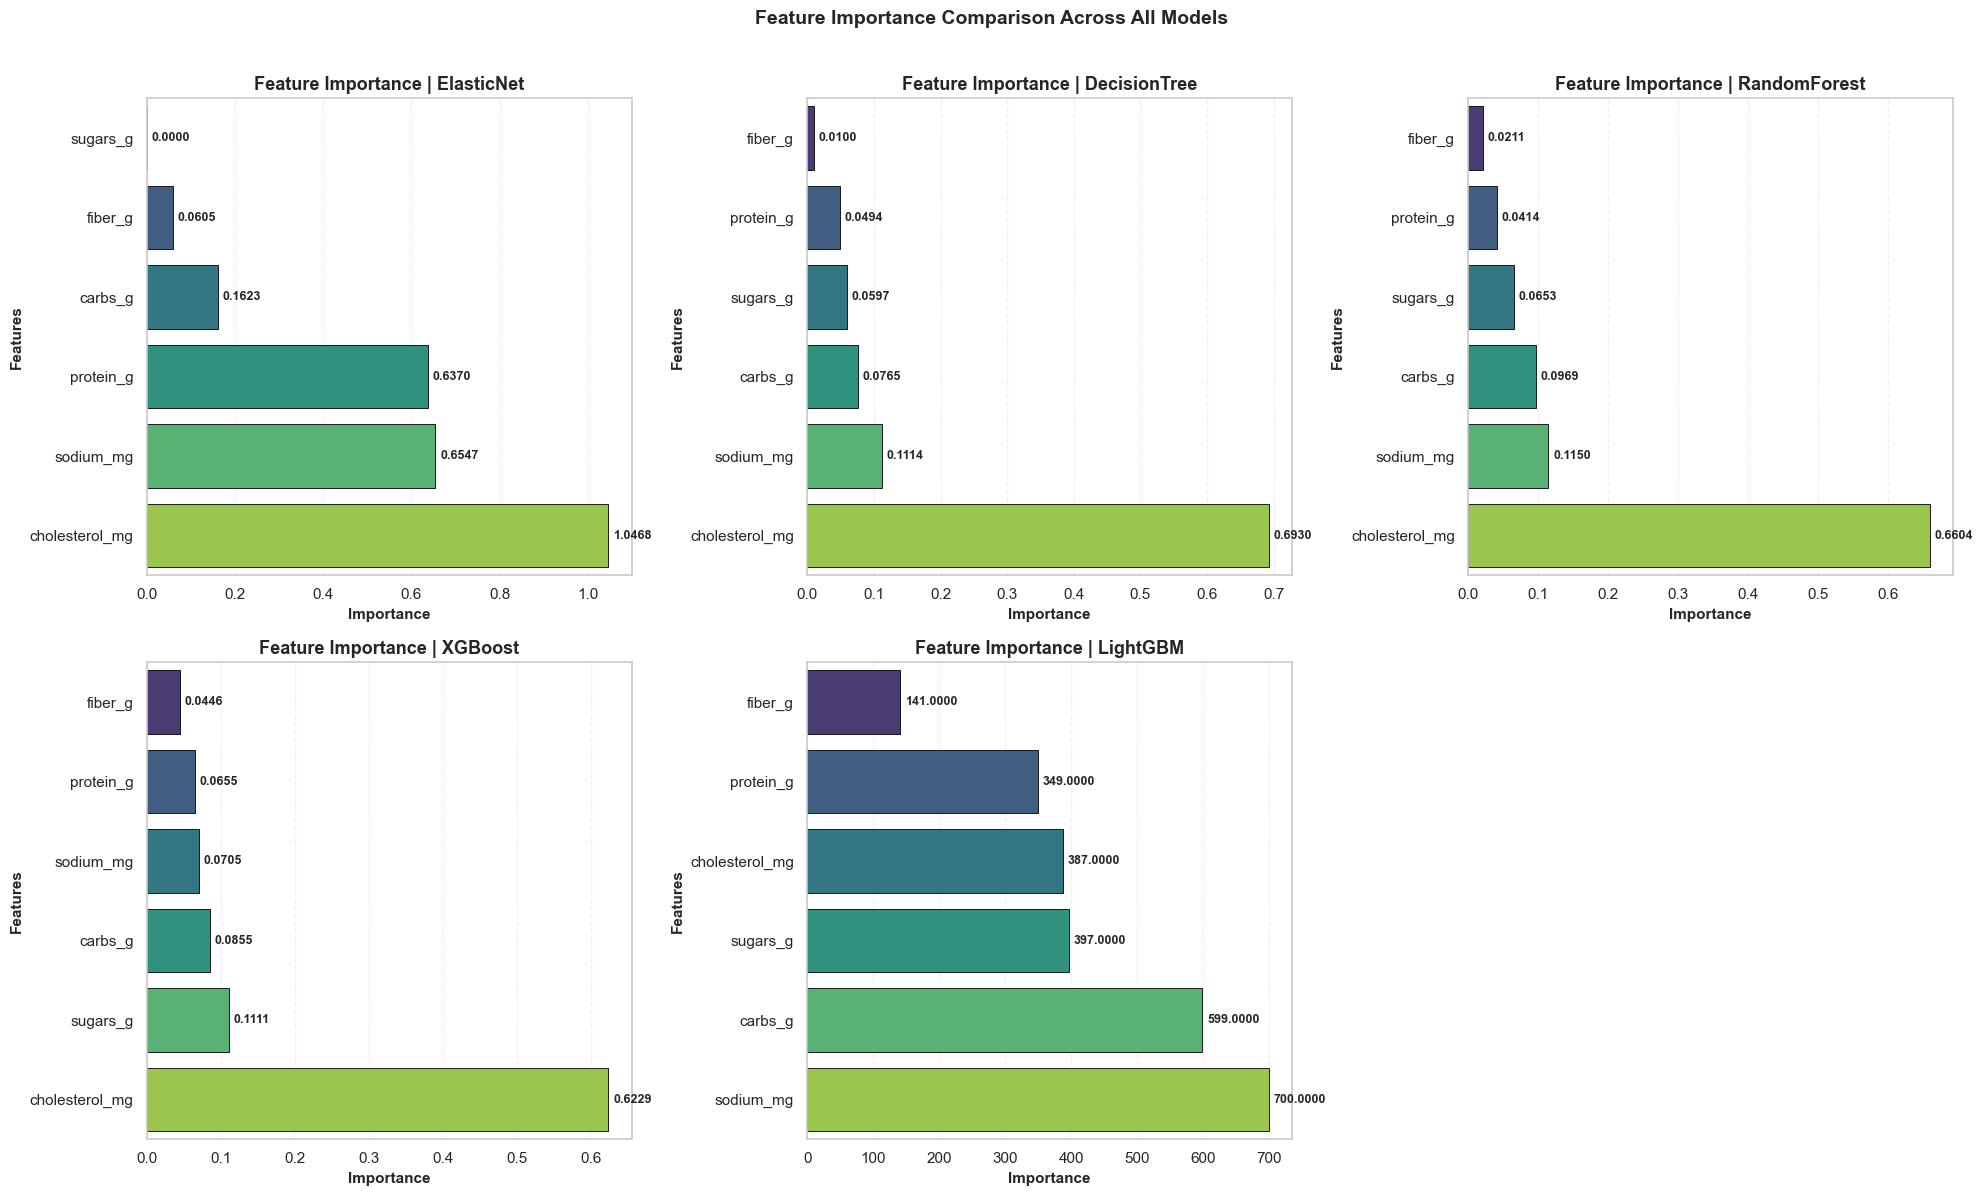

In [14]:
def plot_all_feature_importances(importance_data, save_path=None):
    """
    Vẽ feature importance cho tất cả models trên cùng 1 figure.
    Style tương tự ModelVisualizer.plot_feature_importance()
    
    Parameters
    ----------
    importance_data : dict
        Dictionary với key=model_name, value=importance_df
    save_path : str, optional
        Đường dẫn lưu file
    """
    # Setup figure - 2 hàng x 3 cột cho 5 models (1 subplot trống)
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    # Order models: ElasticNet trước, sau đó các tree-based models (5 models)
    model_order = ['ElasticNet', 'DecisionTree', 'RandomForest', 
                   'XGBoost', 'LightGBM']
    
    for idx, model_name in enumerate(model_order):
        if model_name not in importance_data:
            continue
            
        ax = axes[idx]
        importance_df = importance_data[model_name]
        
        # Sắp xếp ascending để feature quan trọng nhất ở trên
        importance_df_sorted = importance_df.sort_values('importance', ascending=True)
        
        # Tạo color palette
        colors = sns.color_palette("viridis", n_colors=len(importance_df))
        
        # Vẽ horizontal bar chart
        sns.barplot(data=importance_df_sorted, y='feature', x='importance',
                    palette=colors, hue='feature', legend=False, 
                    edgecolor='black', linewidth=0.6, ax=ax)
        
        max_imp = importance_df_sorted['importance'].max()
        for patch, val in zip(ax.patches, importance_df_sorted['importance']):
            ax.text(patch.get_width() + max_imp * 0.01, 
                    patch.get_y() + patch.get_height()/2,
                    f'{val:.4f}', ha='left', va='center', 
                    fontsize=9, fontweight='bold')
        
        ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
        ax.set_ylabel('Features', fontsize=11, fontweight='bold')
        ax.set_title(f'Feature Importance | {model_name}', 
                    fontsize=13, fontweight='bold')
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
    
    # Ẩn subplot trống (vị trí thứ 6)
    axes[5].set_visible(False)
    
    # Tiêu đề chính
    fig.suptitle('Feature Importance Comparison Across All Models', 
                fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    
    # Lưu plot
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.show()


output_path = os.path.join(project_root, 'outputs', 'plots', 'feature_importance_all_models.png')
plot_all_feature_importances(importance_data, save_path=output_path)